In [ ]:
EXPERIMENT 3

In [ ]:
Scenario 1: Multilinear Regression – Student Performance Prediction

Predict student academic performance (final exam score) based on academic, behavioral, and lifestyle features.

Dataset: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams


K.Nivedha(24BAD082)

EXPERIMENT 3

SCENARIO 1: MULTILINEAR REGRESSION

Multilinear Regression Performance:
MSE: 207.05407001047286
RMSE: 14.389373510006363
R2 Score: 0.03411211351611809

Regression Coefficients:
                       Feature  Coefficient
0                  study_hours     0.232854
1                   attendance    -0.402584
2  parental level of education    -1.011591
3      test preparation course    -3.846420
4                  sleep_hours     0.863027

Ridge R2: 0.03415172582084658
Lasso R2: 0.03601731543920195


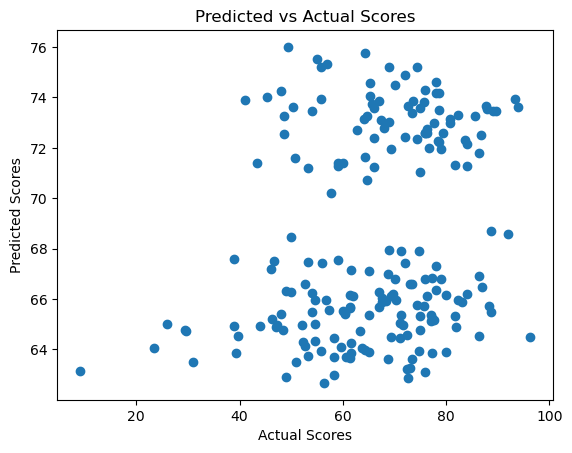

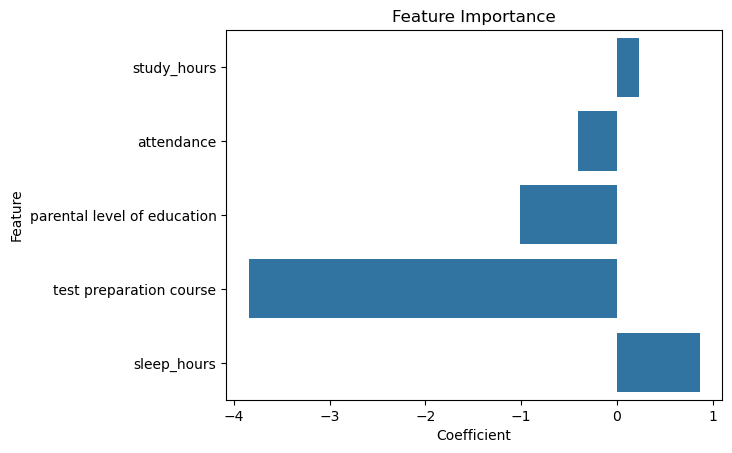

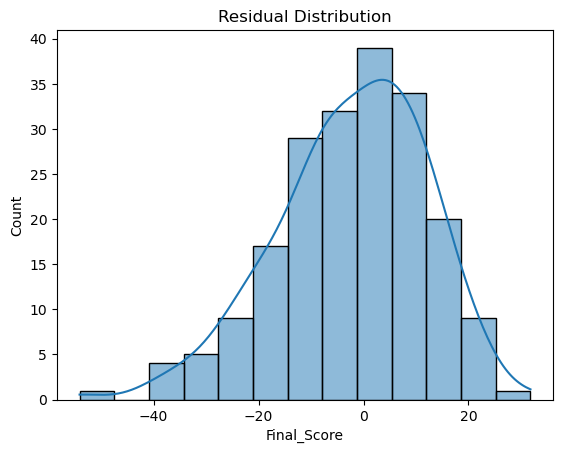

In [1]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 3")
print("\nSCENARIO 1: MULTILINEAR REGRESSION\n")

#Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

#Load Dataset
df = pd.read_csv(r"C:\Users\nived\Downloads\StudentsPerformance.csv")

#Data Preprocessing

#Create Target Variable 
df["Final_Score"] = (df["math score"] + 
                     df["reading score"] + 
                     df["writing score"]) / 3

# Encoding categorical columns
le = LabelEncoder()
df["parental level of education"] = le.fit_transform(df["parental level of education"])
df["test preparation course"] = le.fit_transform(df["test preparation course"])

# Add synthetic features 
np.random.seed(42)
df["study_hours"] = np.random.randint(1, 6, size=len(df))
df["attendance"] = np.random.randint(60, 100, size=len(df))
df["sleep_hours"] = np.random.randint(5, 9, size=len(df))

#Select Features and Target
X = df[["study_hours",
        "attendance",
        "parental level of education",
        "test preparation course",
        "sleep_hours"]]

y = df["Final_Score"]

#Handle Missing Values
X = X.copy()
X = X.fillna(X.mean())


#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

#Train Multilinear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

#Predictions
y_pred = model.predict(X_test)

#Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Multilinear Regression Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

#Coefficient Analysis
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print("\nRegression Coefficients:")
print(coeff_df)

#Regularization

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print("\nRidge R2:", r2_score(y_test, ridge.predict(X_test)))
print("Lasso R2:", r2_score(y_test, lasso.predict(X_test)))

#VISUALIZATION 

#Predicted vs Actual
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Predicted vs Actual Scores")
plt.show()

#Coefficient Magnitude
plt.figure()
sns.barplot(x="Coefficient", y="Feature", data=coeff_df)
plt.title("Feature Importance")
plt.show()

#Residual Plot
residuals = y_test - y_pred
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


In [ ]:
Outcome:
The regression model predicts student performance based on multiple factors. 
Coefficient analysis and regularization techniques help interpret feature influence and improve model stability.

In [ ]:
Scenario 2: Polynomial Regression - Vehicle Fuel Efficiency Prediction

Predict vehicle fuel efficiency (MPG) based on engine characteristics where the relationship is non-linear.

Dataset: https://www.kaggle.com/datasets/uciml/autompg-dataset


K.Nivedha(24BAD082)

EXPERIMENT 3

SCENARIO 2: POLYNOMIAL REGRESSION

Polynomial Regression Results:

Degree: 2
MSE: 18.4169677960178
RMSE: 4.291499481069269
R2 Score: 0.639170114701331
Degree: 3
MSE: 18.460267222224637
RMSE: 4.29654130926547
R2 Score: 0.6383217814053859
Degree: 4
MSE: 18.268226874853166
RMSE: 4.274134634619406
R2 Score: 0.642084284401658
Ridge Regression (Degree 4)
R2 Score: 0.6417265483369177


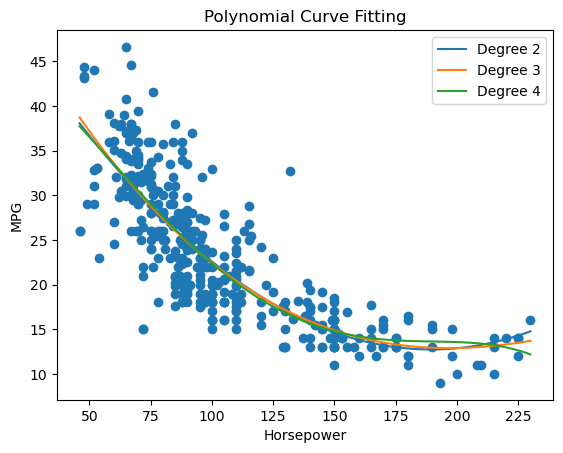

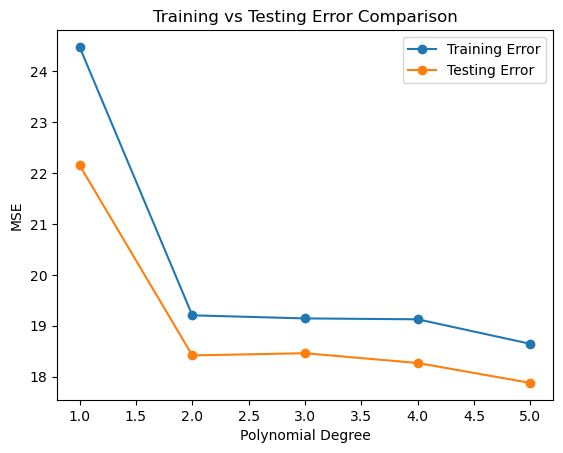

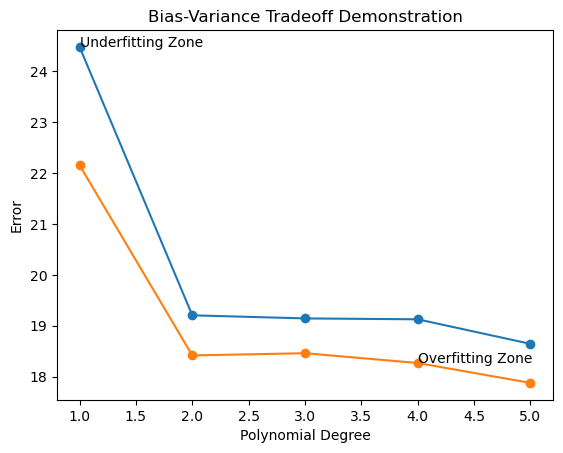

In [2]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 3")
print("\nSCENARIO 2: POLYNOMIAL REGRESSION\n")

#Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

#Load and Clean Dataset
df = pd.read_csv(r"C:\Users\nived\Downloads\auto-mpg.csv")

df = df.replace("?", np.nan)
df["horsepower"] = pd.to_numeric(df["horsepower"])
df = df.dropna()

#Select Feature and Target
X = df[["horsepower"]]
y = df["mpg"]

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Polynomial Regression for Degrees 2,3,4
degrees = [2, 3, 4]

print("Polynomial Regression Results:\n")

for d in degrees:
    
    poly = PolynomialFeatures(degree=d)
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    scaler = StandardScaler()
    X_train_poly = scaler.fit_transform(X_train_poly)
    X_test_poly = scaler.transform(X_test_poly)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_pred = model.predict(X_test_poly)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print("Degree:", d)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    
# 6. Ridge Regularization (Degree 4)
poly = PolynomialFeatures(degree=4)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

ridge = Ridge(alpha=10)
ridge.fit(X_train_poly, y_train)

y_pred_ridge = ridge.predict(X_test_poly)

print("Ridge Regression (Degree 4)")
print("R2 Score:", r2_score(y_test, y_pred_ridge))

# VISUALIZATIONS 

#Polynomial Curve Fitting for Degrees 2,3,4
plt.figure()
plt.scatter(X, y)

X_range = pd.DataFrame(
    np.linspace(X.min().values[0], X.max().values[0], 100),
    columns=["horsepower"]
)

for d in [2,3,4]:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    X_range_poly = poly.transform(X_range)
    y_range_pred = model.predict(X_range_poly)
    
    plt.plot(X_range, y_range_pred, label=f"Degree {d}")

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Curve Fitting")
plt.legend()
plt.show()

#Training vs Testing Error Comparison
train_errors = []
test_errors = []
degrees = [1,2,3,4,5]

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

plt.figure()
plt.plot(degrees, train_errors, marker='o', label="Training Error")
plt.plot(degrees, test_errors, marker='o', label="Testing Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training vs Testing Error Comparison")
plt.legend()
plt.show()

#Overfitting & Underfitting Demonstration
plt.figure()
plt.plot(degrees, train_errors, marker='o')
plt.plot(degrees, test_errors, marker='o')

plt.text(1, train_errors[0], "Underfitting Zone")
plt.text(4, test_errors[3], "Overfitting Zone")

plt.xlabel("Polynomial Degree")
plt.ylabel("Error")
plt.title("Bias-Variance Tradeoff Demonstration")
plt.show()


In [ ]:
Outcome:
The experiment demonstrates non-linear regression, bias-variance tradeoff, and how polynomial regression with regularization can capture complex relationships between horsepower and MPG.